# Projekt 01 (basic) — Faltung & Filter von Hand, und gelernte Filter

**Modul 11 — Computer Vision** · Format: **Jupyter Notebook** (`faltung_filter.ipynb`)

Bevor ein CNN irgendetwas lernt, muss man die **Faltung** verstehen — die Operation, die
allem zugrunde liegt. In diesem Notebook implementierst du die 2D-Faltung selbst, wendest
klassische, **hand-entworfene** Filter (Gauß, Sobel) auf ein echtes Bild an und schlägst
dann die Brücke zum Deep Learning: Du visualisierst die Filter, die ein **vortrainiertes
ResNet** in seiner ersten Schicht *gelernt* hat — und stellst fest, dass sie den
hand-entworfenen Kanten-/Farbdetektoren verblüffend ähneln.

Kernfragen:
- Wie berechnet eine Faltung aus einem Bild + Kernel eine Feature-Map?
- Wie finden **Sobel**-Filter Kanten (Gradientenbetrag)?
- Wie sehen die von einem Netz **gelernten** ersten Filter aus — und warum ist das der
  Beleg dafür, dass „Filter lernen" funktioniert?

> **Viel Anleitung, kein Training.** Alles läuft in Sekunden auf der CPU.


## Setup

Benötigt `numpy`, `matplotlib`, `torch`, `torchvision` (alle in der Repo-`requirements.txt`).
Das Beispielbild (*Grace Hopper*) ist in matplotlib enthalten — kein Download nötig. Das
vortrainierte ResNet18 (~45 MB) wird beim ersten Lauf einmalig geladen und gecached.

```bash
source ../../../../.venv/bin/activate
jupyter lab      # oder faltung_filter.ipynb in VS Code öffnen, Kernel = Repo-.venv
```


## Teil A — Bild laden *(vorgegeben)*

Ein Bild ist ein Zahlenraster. Wir laden ein echtes Foto, wandeln es in **Graustufen**
(eine Matrix $H\times W$ mit Werten in $[0,1]$) und zeigen es an.


Farbbild: (600, 512, 3)  Graustufen: (600, 512)  Wertebereich: 0.0 - 1.0


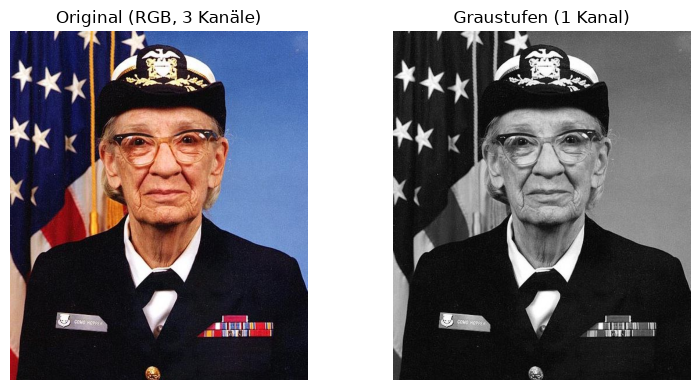

In [1]:
# ---- Bild laden & in Graustufen wandeln (vorgegeben) ----------------------
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cbook as cbook
from PIL import Image

with cbook.get_sample_data("grace_hopper.jpg") as f:
    img_rgb = np.asarray(Image.open(f).convert("RGB")).astype(np.float32) / 255.0

# Graustufen per Luminanz-Gewichtung (ITU-R 601)
gray = img_rgb @ np.array([0.299, 0.587, 0.114], dtype=np.float32)
print("Farbbild:", img_rgb.shape, " Graustufen:", gray.shape, " Wertebereich:",
      round(float(gray.min()), 2), "-", round(float(gray.max()), 2))

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(img_rgb); ax[0].set_title("Original (RGB, 3 Kanäle)"); ax[0].axis("off")
ax[1].imshow(gray, cmap="gray"); ax[1].set_title("Graustufen (1 Kanal)"); ax[1].axis("off")
plt.tight_layout(); plt.show()


### Aufgabe 1 — 2D-Faltung von Hand

Implementiere `convolve2d(image, kernel)` mit **Zero-Padding** („same": Ausgabe so groß wie
Eingabe). Für einen $k\times k$-Kernel $K$ und Bild $I$:
$$(I*K)(i,j)=\sum_{u=0}^{k-1}\sum_{v=0}^{k-1} I_{\text{pad}}(i+u,\,j+v)\,K(u,v).$$

**Effizienz-Tipp (`# TODO`):** Statt über jedes Ausgabepixel zu loopen, loope über die
**$k\times k$ Kernel-Positionen** und akkumuliere jeweils die passend **verschobene**
Bildregion — das ist vollvektorisiert und schnell:

```
out = 0
for u in range(k):
    for v in range(k):
        out += K[u,v] * padded[u : u+H, v : v+W]
```


In [2]:
# ---- AUFGABE 1: 2D-Faltung -----------------------------------------------
def convolve2d(image, kernel):
    """Faltung (Kreuzkorrelation) mit Zero-Padding, Ausgabegröße = Eingabegröße."""
    k = kernel.shape[0]
    p = k // 2
    H, W = image.shape
    padded = np.pad(image, p, mode="constant")
    out = np.zeros((H, W), dtype=np.float32)
    for u in range(k):
        for v in range(k):
            out += kernel[u, v] * padded[u:u + H, v:v + W]
    return out

# Test: Identitäts-Kernel gibt das Bild zurück; Box-Blur glättet
identity = np.array([[0, 0, 0], [0, 1, 0], [0, 0, 0]], dtype=np.float32)
assert np.allclose(convolve2d(gray, identity), gray, atol=1e-5)
box = np.ones((3, 3), dtype=np.float32) / 9.0
blur = convolve2d(gray, box)
print("Identitäts-Test bestanden. Box-Blur berechnet:", blur.shape)


Identitäts-Test bestanden. Box-Blur berechnet: (600, 512)


### Aufgabe 2 — Klassische Filter & Kantendetektion

Wende hand-entworfene Kernel an. Gauß (Glättung) und Schärfen sind vorgegeben. Für die
**Kanten** brauchst du die **Sobel**-Filter und den **Gradientenbetrag**:
$$K_x=\begin{pmatrix}-1&0&1\\-2&0&2\\-1&0&1\end{pmatrix},\quad
K_y=\begin{pmatrix}-1&-2&-1\\0&0&0\\1&2&1\end{pmatrix},\quad
G=\sqrt{G_x^2+G_y^2}.$$

**Deine Aufgabe (`# TODO`):** Berechne $G_x=I*K_x$, $G_y=I*K_y$ und den Gradientenbetrag $G$.


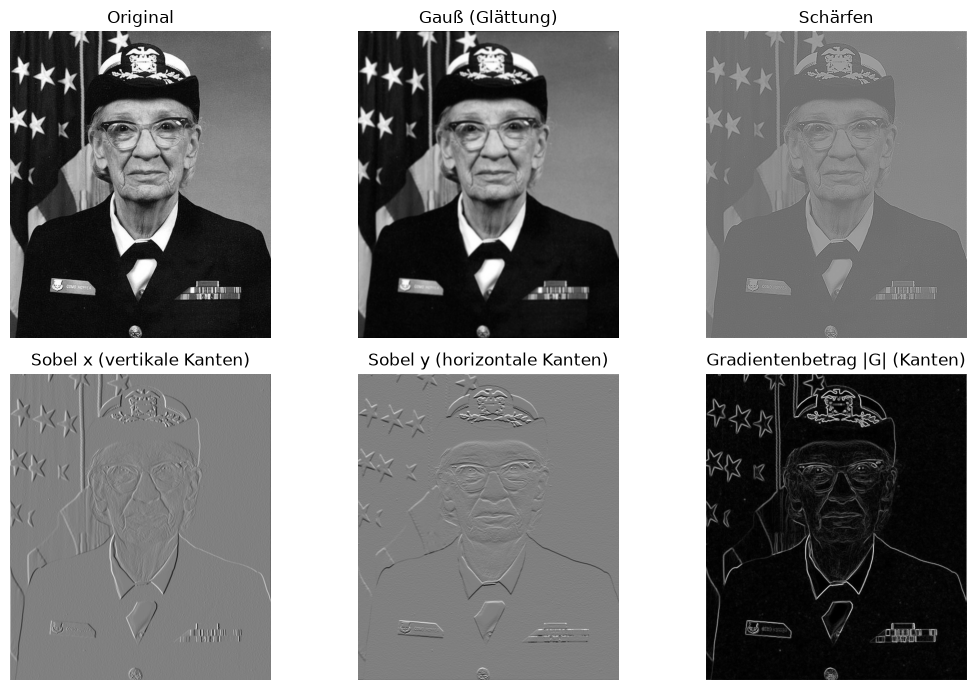

Sobel-Gradientenbetrag: min 0.0 max 4.06


In [3]:
# ---- AUFGABE 2: Sobel-Kanten + vorgegebene Filter -------------------------
# Gauß-Kernel (5x5) und Schärfen (vorgegeben)
def gaussian_kernel(size=5, sigma=1.0):
    ax = np.arange(size) - size // 2
    xx, yy = np.meshgrid(ax, ax)
    g = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    return (g / g.sum()).astype(np.float32)

sharpen = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=np.float32)
Kx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
Ky = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float32)

gauss = convolve2d(gray, gaussian_kernel(5, 1.2))
sharp = convolve2d(gray, sharpen)
# TODO: Sobel in x und y + Gradientenbetrag
Gx = convolve2d(gray, Kx)
Gy = convolve2d(gray, Ky)
G = np.sqrt(Gx**2 + Gy**2)

fig, ax = plt.subplots(2, 3, figsize=(11, 7))
for a, im, t in zip(ax.ravel(),
                    [gray, gauss, sharp, Gx, Gy, G],
                    ["Original", "Gauß (Glättung)", "Schärfen",
                     "Sobel x (vertikale Kanten)", "Sobel y (horizontale Kanten)",
                     "Gradientenbetrag |G| (Kanten)"]):
    a.imshow(im, cmap="gray"); a.set_title(t); a.axis("off")
plt.tight_layout(); plt.show()
print("Sobel-Gradientenbetrag: min", round(float(G.min()),2), "max", round(float(G.max()),2))


### Aufgabe 3 — *Gelernte* Filter eines pretrained Netzes

Jetzt die Brücke zum Deep Learning: Ein CNN **entwirft** seine Filter nicht, es **lernt**
sie aus Daten. Wir laden ein **vortrainiertes ResNet18** und schauen uns seine allererste
Faltungsschicht an — 64 Filter der Form $3\times7\times7$ (RGB). Visualisiert man sie,
sieht man **Kanten- und Farbdetektoren** — genau die Art Filter, die du oben von Hand
gebaut hast, nur aus 1,2 Mio. ImageNet-Bildern gelernt.

**Deine Aufgabe (`# TODO`):** Schicke das (vorverarbeitete) Bild durch `conv1` und
visualisiere ein paar der resultierenden **Feature-Maps**.


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/timonludwig/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


  0%|          | 0.00/44.7M [00:00<?, ?B/s]

  4%|▍         | 1.75M/44.7M [00:00<00:02, 18.1MB/s]

 27%|██▋       | 12.2M/44.7M [00:00<00:00, 69.3MB/s]

 55%|█████▌    | 24.6M/44.7M [00:00<00:00, 95.9MB/s]

 82%|████████▏ | 36.5M/44.7M [00:00<00:00, 107MB/s] 

100%|██████████| 44.7M/44.7M [00:00<00:00, 98.2MB/s]

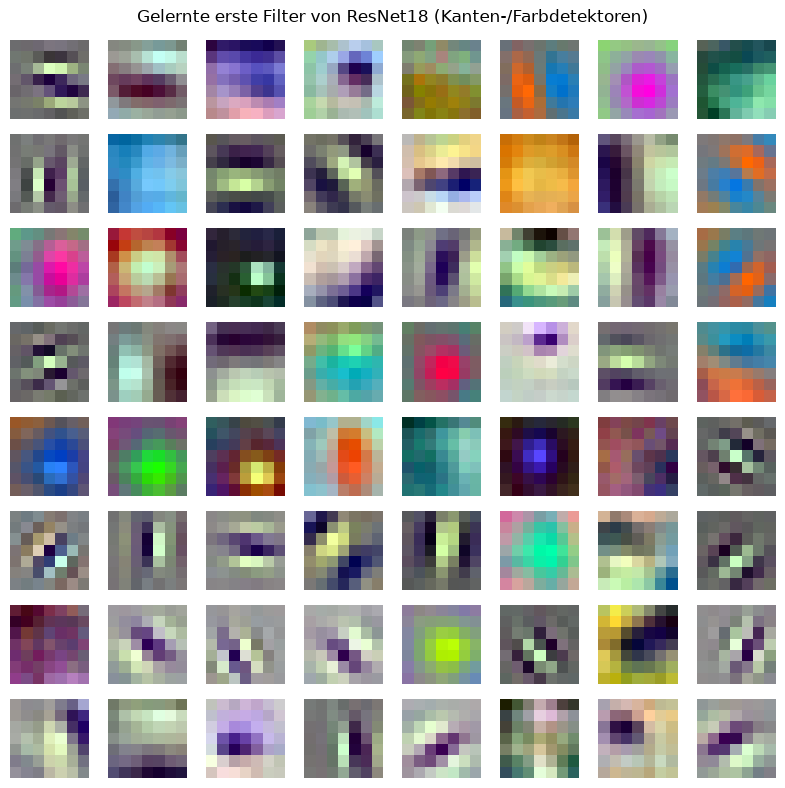

Feature-Map-Tensor: (1, 64, 112, 112)


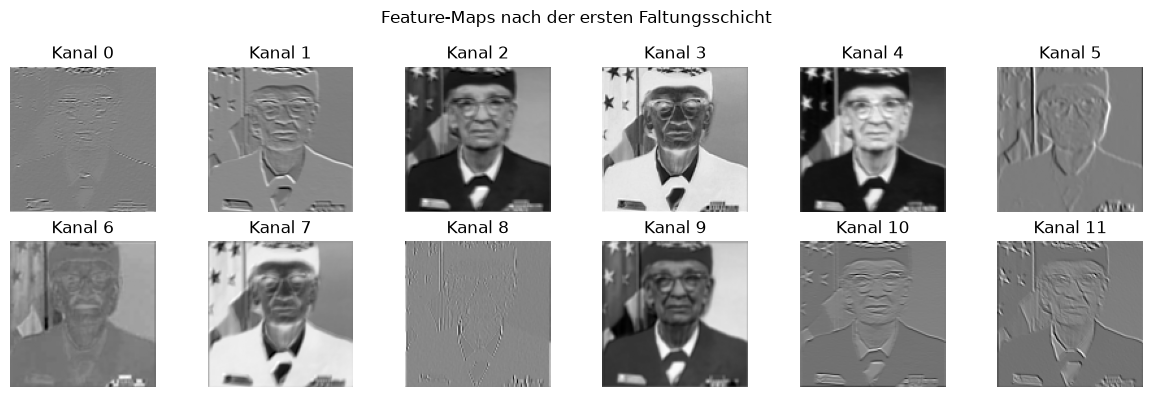

In [4]:
# ---- AUFGABE 3: gelernte erste Filter + Feature-Maps ----------------------
import torch
from torchvision.models import resnet18, ResNet18_Weights

weights = ResNet18_Weights.IMAGENET1K_V1
model = resnet18(weights=weights).eval()

# (a) die 64 gelernten conv1-Filter (3x7x7) als kleine RGB-Bilder (vorgegeben)
filters = model.conv1.weight.detach().numpy()          # (64, 3, 7, 7)
def norm01(a):
    return (a - a.min()) / (a.max() - a.min() + 1e-8)
fig, axes = plt.subplots(8, 8, figsize=(8, 8))
for i, a in enumerate(axes.ravel()):
    a.imshow(norm01(filters[i].transpose(1, 2, 0))); a.axis("off")
fig.suptitle("Gelernte erste Filter von ResNet18 (Kanten-/Farbdetektoren)")
plt.tight_layout(); plt.show()

# (b) Bild durch conv1 schicken und Feature-Maps zeigen
preprocess = weights.transforms()
x = preprocess(Image.fromarray((img_rgb * 255).astype(np.uint8))).unsqueeze(0)  # (1,3,224,224)
# TODO: feats = model.conv1(x)  (unter torch.no_grad); Form (1,64,112,112)
with torch.no_grad():
    feats = model.conv1(x)
print("Feature-Map-Tensor:", tuple(feats.shape))
fmaps = feats[0].detach().numpy()
fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for i, a in enumerate(axes.ravel()):
    a.imshow(fmaps[i], cmap="gray"); a.set_title(f"Kanal {i}"); a.axis("off")
fig.suptitle("Feature-Maps nach der ersten Faltungsschicht")
plt.tight_layout(); plt.show()


## Reflexion (kurz, schriftlich)

1. **Faltung:** Warum liefert der Sobel-x-Filter an einer *vertikalen* Kante einen großen
   Betrag, in einer homogenen Fläche aber ~0? (Beziehe dich auf die Kernel-Gewichte.)
2. **Padding:** Was passierte ohne Zero-Padding mit der Bildgröße, und warum ist „same"-
   Padding praktisch?
3. **Hand vs. gelernt:** Vergleiche die ResNet-`conv1`-Filter mit deinen hand-entworfenen.
   Was ist die zentrale Erkenntnis über CNNs (Abschnitt 1.3/2 des Skripts)?
4. **Hierarchie:** conv1 zeigt Kanten/Farben. Was würden *tiefere* Schichten stattdessen
   detektieren, und warum kann man sie nicht so einfach als 7×7-Bild visualisieren?

> **Referenz:** Der Gradientenbetrag zeichnet die Konturen (Gesicht, Uniform) klar nach;
> die 64 gelernten conv1-Filter zeigen gerichtete Kanten und Farb-Blobs — die
> „ImageNet-Version" deiner Sobel/Gauß-Kernel.
